# **!!_2 Geometric interpretation of NNF**


Q = 20, N_x = 1, N_y = 1
N_min = 1.8790, N_max = 32.0000


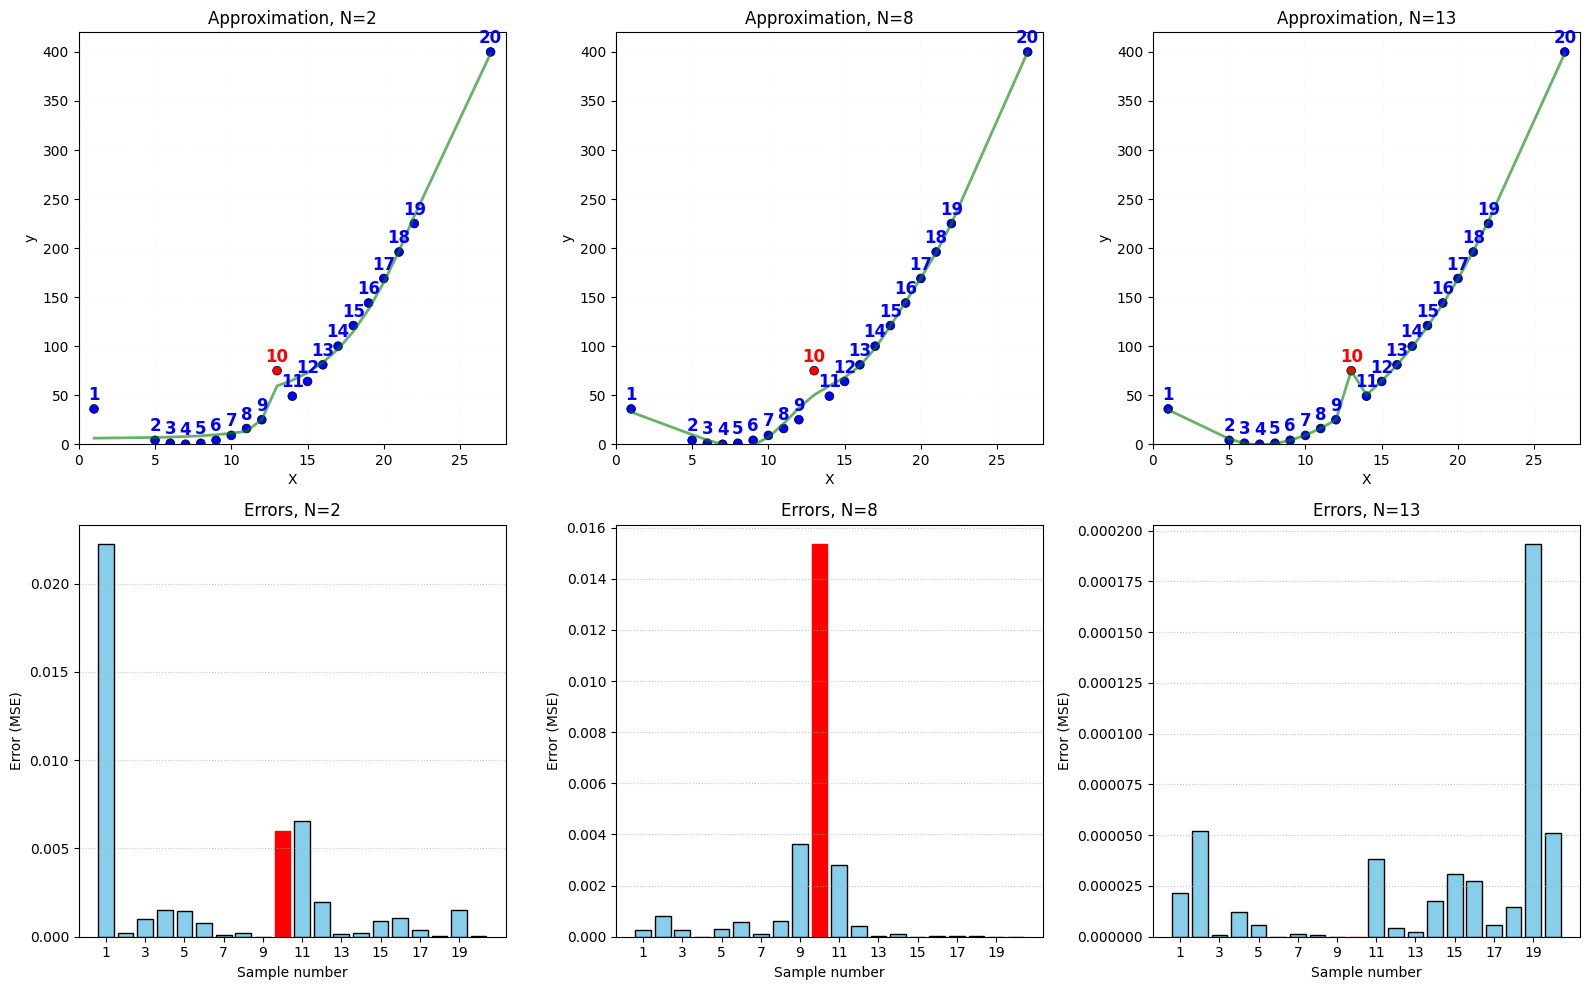

In [ ]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Original data (from the table)
# ------------------------------------------------------------
data = [
    (1, 1, 36), (2, 5, 4), (3, 6, 1), (4, 7, 0), (5, 8, 1),
    (6, 9, 4), (7, 10, 9), (8, 11, 16), (9, 12, 25), (10, 13, 75),
    (11, 14, 49), (12, 15, 64), (13, 16, 81), (14, 17, 100),
    (15, 18, 121), (16, 19, 144), (17, 20, 169), (18, 21, 196),
    (19, 22, 225), (20, 27, 400)
]

X = np.array([row[1] for row in data], dtype=np.float32).reshape(-1, 1)
y = np.array([row[2] for row in data], dtype=np.float32).reshape(-1, 1)

Q = X.shape[0]          # number of samples = 20
N_x = X.shape[1]        # 1 input feature
N_y = y.shape[1]        # 1 output variable

# ------------------------------------------------------------
# 2. Calculation of the hidden layer neuron count bounds
# ------------------------------------------------------------
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y))
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1)

print("\n" + "="*50)
print(f"Q = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")
print("="*50)

# Index of the outlier (sample #10)
outlier_idx = 9

# ------------------------------------------------------------
# 3. Scaling to [-1, 1]
# ------------------------------------------------------------
def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled, x_min, x_max = scale_to_minus1_1(X)
y_scaled, y_min, y_max = scale_to_minus1_1(y)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)


# ------------------------------------------------------------
# 4. Training networks for N = 2, 8, 13 and collecting results
# ------------------------------------------------------------
N_list = [2, 8, 13]
predictions_scaled = {}   # predictions in scaled coordinates
errors = {}               # squared errors (in scaled coordinates)

for N in N_list:
    torch.manual_seed(42)  # fix for reproducibility
    model = nn.Sequential(
        nn.Linear(N_x, N),
        nn.Tanh(),
        nn.Linear(N, N_y),
    )
    criterion = nn.MSELoss()
    optimizer = optim.Rprop(model.parameters())

    # Training
    model.train()
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    # Predictions and errors
    model.eval()
    with torch.no_grad():
        pred = model(X_tensor).numpy().flatten()
        err = (pred - y_scaled.flatten()) ** 2
    predictions_scaled[N] = pred
    errors[N] = err

# ------------------------------------------------------------
# 5. Building the composite figure (2 rows, 3 columns)
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))

# General settings
x_orig = X.flatten()
y_orig = y.flatten()
x_smooth = np.linspace(X.min(), X.max(), 200)  # for smooth curve (not used, but kept)

for i, N in enumerate(N_list):
    # Top row: approximation
    ax_top = plt.subplot(2, 3, i+1)
    # Original points
    colors = ['red' if j == outlier_idx else 'blue' for j in range(Q)]
    ax_top.scatter(x_orig, y_orig, c=colors, s=40, edgecolors='black', linewidth=0.5)

    # Add sample numbers (1 to 20) next to the points
    for j in range(Q):
        text_color = 'red' if j == outlier_idx else 'blue'
        ax_top.text(x_orig[j], y_orig[j] + 5, str(j+1), fontsize=12,
                    ha='center', va='bottom', color=text_color, fontweight='bold')

    # Approximating curve (piecewise linear through points) with transparency 0.6
    pred_orig = (predictions_scaled[N] + 1) / 2 * (y_max - y_min) + y_min
    sort_idx = np.argsort(x_orig)
    ax_top.plot(x_orig[sort_idx], pred_orig[sort_idx], 'g-', linewidth=2, alpha=0.6, label=f'N={N}')

    ax_top.set_xlim(0, 28)
    ax_top.set_ylim(0, 420)
    ax_top.set_xlabel('X')
    ax_top.set_ylabel('y')
    ax_top.set_title(f'Approximation, N={N}')
    ax_top.grid(True, linestyle=':', alpha=0.05)

    # Bottom row: errors
    ax_bottom = plt.subplot(2, 3, i+4)  # indices 4,5,6 for the three plots
    examples = np.arange(1, Q+1)
    bars = ax_bottom.bar(examples, errors[N], color='skyblue', edgecolor='black')
    # highlight the outlier in red
    bars[outlier_idx].set_color('red')
    ax_bottom.set_xlabel('Sample number')
    ax_bottom.set_ylabel('Error (MSE)')
    ax_bottom.set_title(f'Errors, N={N}')
    ax_bottom.set_xticks(examples[::2])
    ax_bottom.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()